# Funny's company

En este documento se encuentra el desarrollo realizado para obtener y visualizar una solución óptima para resolver el problema correspondiente a la creciente demanda.

Se presentará una guía paso a paso por si se quieren comprobar los resultados o utilizar otros parámetros


## Creación del modelo

### 1.

Primero se deben instalar e importar las librerías correspondientes, se utilizará gurobipy para resolver el problema y cartopy para visualizar el resultado.

In [5]:
!pip install gurobipy
from gurobipy import Model, GRB, quicksum

!pip install cartopy
import cartopy

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 58.8 MB/s eta 0:00:00


### 2.
Se definen los distintos tipos de conjuntos y se guardan en listas.

In [6]:
# Datos del problema
regiones = ["R1", "R2", "R3", "R4", "R5", "R6"]
ciudades = ["Antofagasta", "Valparaíso", "Santiago", "Concepción", "Puerto Montt", "Rancagua"]# Rancagua no estaba
tipos_planta = ["Pequeña", "Grande"]
transportes = ["AT1", "AT2", "AT3"]
años = [1, 2, 3]

### 3.
Se guardan los parámetros en diccionarios, donde la llave estará definida por detos de los conjuntos antes presentados.

In [7]:
# Demanda anual de la región k (en el año t)
demanda_actual = {
    "R1": 951776, "R2": 967364, "R3": 512051, "R4": 386248, "R5": 946174, "R6": 303445
}

# Tasa de crecimiento de la demanda de la planta j
tasas_crecimiento = {
    "R1": 0.16, "R2": 0.22, "R3": 0.26, "R4": 0.15, "R5": 0.39, "R6": 0.30
}

# capacidad de producción de la planta j (en tiempo t)
capacidad_planta = {"Pequeña": 4636446, "Grande": 14966773}

# Costo anual de operacion de una planta tipo j en la ciudad i (en el año t)
costos_fijos = {
    ("Antofagasta", "Pequeña"): 18236639, ("Antofagasta", "Grande"): 60788796,
    ("Valparaíso", "Pequeña"):   8838286, ("Valparaíso", "Grande"): 32734393,
    ("Santiago", "Pequeña"):     6840758, ("Santiago", "Grande"): 32575039,
    ("Rancagua", "Pequeña"):    13378246, ("Rancagua", "Grande"): 53512984,
    ("Concepción", "Pequeña"):  26394217, ("Concepción", "Grande"): 65985543,
    ("Puerto Montt", "Pequeña"): 3678737, ("Puerto Montt", "Grande"): 26276695
}

# Costo variable de producción por unidad (independiente del tipo de planta)
costos_variables = {
    "Antofagasta": 28.20,
    "Valparaíso": 41.68,
    "Santiago": 18.57,
    "Rancagua": 17.68,
    "Concepción": 50.11,
    "Puerto Montt": 43.55
}

# Costo de apertura de una planta j en una ciudad i
costos_apertura = {
    ("Antofagasta", "Pequeña"): 86626147, ("Antofagasta", "Grande"): 201456157,
    ("Valparaíso", "Pequeña"): 115721215, ("Valparaíso", "Grande"): 199519337,
    ("Santiago", "Pequeña"): 172235977, ("Santiago", "Grande"): 291925385,
    ("Rancagua", "Pequeña"): 0, ("Rancagua", "Grande"): 299031830,
    ("Concepción", "Pequeña"): 57494934, ("Concepción", "Grande"): 179671671,
    ("Puerto Montt", "Pequeña"): 175561277, ("Puerto Montt", "Grande"): 337617842
}

# Costo de transporte por unidad desde ciudad i hasta region k con transportista f (en año t)
costos_transporte = {
    ("AT1", "Antofagasta", "R1"): 1.06, ("AT1", "Antofagasta", "R2"): 2.80, ("AT1", "Antofagasta", "R3"): 10.29,
    ("AT1", "Antofagasta", "R4"): 4.87, ("AT1", "Antofagasta", "R5"): 6.41, ("AT1", "Antofagasta", "R6"): 10.35,
    ("AT1", "Valparaíso", "R1"): 3.49, ("AT1", "Valparaíso", "R2"): 6.19, ("AT1", "Valparaíso", "R3"): 3.39,
    ("AT1", "Valparaíso", "R4"): 6.77, ("AT1", "Valparaíso", "R5"): 3.07, ("AT1", "Valparaíso", "R6"): 6.61,
    ("AT1", "Santiago", "R1"): 6.38, ("AT1", "Santiago", "R2"): 5.88, ("AT1", "Santiago", "R3"): 5.63,
    ("AT1", "Santiago", "R4"): 1.01, ("AT1", "Santiago", "R5"): 3.15, ("AT1", "Santiago", "R6"): 5.67,
    ("AT1", "Rancagua", "R1"): 3.44, ("AT1", "Rancagua", "R2"): 1.48, ("AT1", "Rancagua", "R3"): 2.79,
    ("AT1", "Rancagua", "R4"): 2.80, ("AT1", "Rancagua", "R5"): 5.30, ("AT1", "Rancagua", "R6"): 1.29,
    ("AT1", "Concepción", "R1"): 5.94, ("AT1", "Concepción", "R2"): 7.33, ("AT1", "Concepción", "R3"): 1.80,
    ("AT1", "Concepción", "R4"): 9.48, ("AT1", "Concepción", "R5"): 2.82, ("AT1", "Concepción", "R6"): 8.25,
    ("AT1", "Puerto Montt", "R1"): 2.57, ("AT1", "Puerto Montt", "R2"): 9.63, ("AT1", "Puerto Montt", "R3"): 4.84,
    ("AT1", "Puerto Montt", "R4"): 6.64, ("AT1", "Puerto Montt", "R5"): 6.48, ("AT1", "Puerto Montt", "R6"): 8.54,
    ("AT2", "Antofagasta", "R1"): 10.03, ("AT2", "Antofagasta", "R2"): 4.09, ("AT2", "Antofagasta", "R3"): 4.55,
    ("AT2", "Antofagasta", "R4"): 7.84, ("AT2", "Antofagasta", "R5"): 5.33, ("AT2", "Antofagasta", "R6"): 10.63,
    ("AT2", "Valparaíso", "R1"): 10.52, ("AT2", "Valparaíso", "R2"): 1.82, ("AT2", "Valparaíso", "R3"): 3.91,
    ("AT2", "Valparaíso", "R4"): 8.20, ("AT2", "Valparaíso", "R5"): 5.88, ("AT2", "Valparaíso", "R6"): 2.33,
    ("AT2", "Santiago", "R1"): 1.90, ("AT2", "Santiago", "R2"): 8.89, ("AT2", "Santiago", "R3"): 6.55,
    ("AT2", "Santiago", "R4"): 9.71, ("AT2", "Santiago", "R5"): 7.03, ("AT2", "Santiago", "R6"): 10.23,
    ("AT2", "Rancagua", "R1"): 2.06, ("AT2", "Rancagua", "R2"): 10.17, ("AT2", "Rancagua", "R3"): 2.12,
    ("AT2", "Rancagua", "R4"): 6.11, ("AT2", "Rancagua", "R5"): 3.79, ("AT2", "Rancagua", "R6"): 6.19,
    ("AT2", "Concepción", "R1"): 2.54, ("AT2", "Concepción", "R2"): 6.95, ("AT2", "Concepción", "R3"): 8.57,
    ("AT2", "Concepción", "R4"): 10.50, ("AT2", "Concepción", "R5"): 4.85, ("AT2", "Concepción", "R6"): 5.31,
    ("AT2", "Puerto Montt", "R1"): 7.92, ("AT2", "Puerto Montt", "R2"): 10.32, ("AT2", "Puerto Montt", "R3"): 1.41,
    ("AT2", "Puerto Montt", "R4"): 4.94, ("AT2", "Puerto Montt", "R5"): 2.74, ("AT2", "Puerto Montt", "R6"): 8.08,
    ("AT3", "Antofagasta", "R1"): 9.86, ("AT3", "Antofagasta", "R2"): 4.30, ("AT3", "Antofagasta", "R3"): 8.10,
    ("AT3", "Antofagasta", "R4"): 9.63, ("AT3", "Antofagasta", "R5"): 7.40, ("AT3", "Antofagasta", "R6"): 6.47,
    ("AT3", "Valparaíso", "R1"): 1.58, ("AT3", "Valparaíso", "R2"): 2.71, ("AT3", "Valparaíso", "R3"): 3.08,
    ("AT3", "Valparaíso", "R4"): 5.91, ("AT3", "Valparaíso", "R5"): 7.99, ("AT3", "Valparaíso", "R6"): 5.11,
    ("AT3", "Santiago", "R1"): 9.13, ("AT3", "Santiago", "R2"): 10.03, ("AT3", "Santiago", "R3"): 6.77,
    ("AT3", "Santiago", "R4"): 5.70, ("AT3", "Santiago", "R5"): 3.62, ("AT3", "Santiago", "R6"): 8.58,
    ("AT3", "Rancagua", "R1"): 8.95, ("AT3", "Rancagua", "R2"): 7.37, ("AT3", "Rancagua", "R3"): 10.29,
    ("AT3", "Rancagua", "R4"): 3.34, ("AT3", "Rancagua", "R5"): 2.21, ("AT3", "Rancagua", "R6"): 4.58,
    ("AT3", "Concepción", "R1"): 9.62, ("AT3", "Concepción", "R2"): 3.78, ("AT3", "Concepción", "R3"): 5.19,
    ("AT3", "Concepción", "R4"): 2.61, ("AT3", "Concepción", "R5"): 3.19, ("AT3", "Concepción", "R6"): 1.78,
    ("AT3", "Puerto Montt", "R1"): 10.32, ("AT3", "Puerto Montt", "R2"): 8.88, ("AT3", "Puerto Montt", "R3"): 10.87,
    ("AT3", "Puerto Montt", "R4"): 10.38, ("AT3", "Puerto Montt", "R5"): 5.83, ("AT3", "Puerto Montt", "R6"): 1.54
}


### 4.
Se crea el modelo y las variables de decisión, donde:
- X = cantidad de productos transportados desde la ciudad $c$ a la región $r$ usando el transporte $t$ en el año $a$
- Y = se abre una planta de tamaño $p$ en la ciudad $c$

In [8]:
# Crear el modelo
m = Model("FunnysCompany")

# Variables de decisión
x = m.addVars(ciudades, regiones, transportes, años, vtype=GRB.INTEGER, name="x")
y = m.addVars(ciudades, tipos_planta, vtype=GRB.BINARY, name="y") #BINARY o INTEGER

Restricted license - for non-production use only - expires 2027-11-29


### 5.

Se define la función objetivo, donde se minimizan los gastos relacionados con la apertura de las plantas (costo fijo y de apertura), y gastos relacionados con los productos, los cuales corresponden a el transporte y producción.

In [9]:

# Función objetivo
m.setObjective(
    quicksum((costos_apertura[(c, p)] + 3 * costos_fijos[(c, p)]) * y[c, p] for c in ciudades for p in tipos_planta) +
    quicksum((costos_transporte[(t, c, r)]) * x[c, r, t, an] for c in ciudades for r in regiones for t in transportes for an in años) +
    quicksum(costos_variables[c] * x[c, r, t, an] for c in ciudades for r in regiones for t in transportes for an in años),
    GRB.MINIMIZE
)


### 6.
Se definen las restricciones;
- Planta existente en rancagua
- la demanda se tiene que satisfacer
- solo se puede instalar una planta por ciudad
- solo puede existir una planta pequeña (ademas de Rancagua)
- solo puede existir una planta grande
- la cantidad de productos transportados desde una ciudad tiene que ser menor a su capacidad máxima

In [10]:
# Restricciones
# Condición inicial (Planta existente en rancagua)
m.addConstr(y["Rancagua", "Pequeña"] == 1)

# Satisfaccion de la demanda
for r in regiones:
    for an in años:
        m.addConstr(quicksum(x[c, r, t, an] for c in ciudades for t in transportes) >= demanda_actual[r] * (1 + tasas_crecimiento[r]) ** (an - 1), name=f"demanda_satisfecha_{r}_{an}")

# Limite de instalación por ciudad
for c in ciudades:
   m.addConstr(quicksum(y[c,p] for p in tipos_planta) <= 1 , name="1 planta por ciudad") # HAY QUE COMENTAR ESTA RESTRICCION PARA LA PREGUNTA 5

# Límite de cantidad de plantas pequeñas a nivel nacional
m.addConstr(quicksum(y[c, "Pequeña"] for c in ciudades) <= 2, name="max_pequenas_nacional")

# Límite de cantidad de plantas grandes a nivel nacional
m.addConstr(quicksum(y[c, "Grande"] for c in ciudades) <= 1, name="max_grandes_nacional")

# Balance de produccion y capacidad
for c in ciudades:
    for an in años:
        m.addConstr(quicksum(x[c, r, t, an] for r in regiones for t in transportes) <= quicksum(capacidad_planta[p] * y[c,p] for p in tipos_planta), name=f"balance_produccion_{c}_{an}")


### 7.
Se presentan los resultados

In [11]:
# x = cantidad transportada desde c a r en transporte t durante a
# y = 1 si se instala planta tipo p en c, 0 si no

# Optimizar el modelo
m.optimize()


# Mostrar resultados
if m.status == GRB.OPTIMAL:


    for c in ciudades:
        for p in tipos_planta:
            if y[c, p].X > 0.5:
                print(f"Instalar planta {p} en {c}")

    for c in ciudades:
        for r in regiones:
            for t in transportes:
                for an in años:
                    if x[c, r, t, an].X > 0:
                        print(f"Transportar {x[c, r, t, an].X} unidades desde {c} a {r} usando {t} en el año {an}")

    for c in ciudades:
        for p in tipos_planta:
            if y[c, p].x > 0:
                print(f"Instalar {y[c, p].x} planta(s) de tipo {p} en {c}")


# Cálculo de los costos totales actualizado
    total_apertura = sum(costos_apertura[(c, p)] * y[c, p].X for c in ciudades for p in tipos_planta)
    total_fijo = sum(3 * costos_fijos[(c, p)] * y[(c, p)].X for c in ciudades for p in tipos_planta)
    total_variable = sum(costos_variables[c] * x[c, r, t, an].X for c in ciudades
                         for r in regiones for t in transportes for an in años)
    total_transporte = sum(costos_transporte[(t, c, r)] * x[c, r, t, an].X for c in ciudades for r in regiones
                           for t in transportes for an in años)

    total_general = total_apertura + total_fijo + total_variable + total_transporte

    # Impresión de resultados
    print("\n--- Resultados del Modelo ---")
    print(f"Costo total de apertura: {total_apertura}")
    print(f"Costo total fijo: {total_fijo}")
    print(f"Costo total variable: {total_variable}")
    print(f"Costo total de transporte: {total_transporte}")
    print(f"Costo total general: {total_general}")

    print("\n--- Plan de Transporte ---")
    for c in ciudades:
        for r in regiones:
            for t in transportes:
                for an in años:
                    if x[c, r, t, an].X > 0:
                        print(f"Año {an}: Transportar {x[c, r, t, an].X} unidades desde {c} a {r} usando {t}")

    print("\n--- Producción Anual de Plantas ---")

    # Comparativo entre demanda y unidades transportadas
    print("\n--- Comparativo Demanda vs. Transporte ---")
    for r in regiones:
        for an in años:
            demanda = demanda_actual[r] * (1 + tasas_crecimiento[r]) ** (an - 1)
            transporte_total = sum(x[c, r, t, an].X for c in ciudades for t in transportes)
            print(f"Año {an} - Región {r}:")
            print(f"  Demanda: {demanda}")
            print(f"  Unidades transportadas: {transporte_total}")
            print(f"  Diferencia: {transporte_total - demanda}\n")

    # Comparativo entre demanda y capacidad de plantas
    print("\n--- Comparativo Demanda vs. Capacidad de Plantas ---")
    demanda_t = {}
    for an in años:
        # Calcular la demanda total para todas las regiones en el año `an`
        demanda_total_anual = sum(demanda_actual[r] * (1 + tasas_crecimiento[r]) ** (an - 1) for r in regiones)

        # Calcular la capacidad total disponible en todas las plantas en el año `an`
        capacidad_total_anual = sum(capacidad_planta[p] * y[c, p].X for c in ciudades for p in tipos_planta)

        print(f"Año {an}:")
        print(f"  Demanda Total: {demanda_total_anual}")
        print(f"  Capacidad Total de las Plantas: {capacidad_total_anual}")
        print(f"  Diferencia (Capacidad - Demanda): {capacidad_total_anual - demanda_total_anual}\n")
        demanda_t[an] = demanda_total_anual



    # Resumen por año
    print("\n--- Resumen por Año ---")
    for an in años:
      print("########################\n")
      print(f"Año {an}:")
      dic = {}
      for c in ciudades:
          for r in regiones:
              for t in transportes:
                  if x[c,r,t,an].X >0:
                      if c not in dic:
                        dic[c] = 0
                      dic[c] = dic[c] + x[c,r,t,an].X
      print(f" Demanda total: {demanda_t[an]}")
      print(" Unidades transportadas:")
      for k in dic:
        print(f"  {k}: {dic[k]}")
      print(f" Un total de ", sum(dic.values()), " unidades transportadas\n")



Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 45 rows, 336 columns and 709 nonzeros (Min)
Model fingerprint: 0xcd38a34f
Model has 336 linear objective coefficients
Variable types: 0 continuous, 336 integer (12 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+07]
  Objective range  [2e+01, 5e+08]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+06]

Found heuristic solution: objective 9.936112e+08
Presolve removed 13 rows and 253 columns
Presolve time: 0.00s
Presolved: 32 rows, 83 columns, 187 nonzeros
Found heuristic solution: objective 9.591575e+08
Variable types: 0 continuous, 83 integer (11 binary)

Root relaxation: objective 4.153555e+08, 33 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |

## Visualización de los resultados

### 1.
se definen las coordenadas de las ciudades y regiones

In [12]:
coords = {
    "Antofagasta": (-23.65, -70.40),
    "Valparaíso": (-33.05, -71.61),
    "Santiago": (-33.45, -70.66),
    "Rancagua": (-34.17, -70.74),
    "Concepción": (-36.82, -73.04),
    "Puerto Montt": (-41.47, -72.94),
    "R1": (-20.21, -70.14),
    "R2": (-23.65, -70.40),
    "R3": (-27.36, -70.33),
    "R4": (-29.90, -71.25),
    "R5": (-33.05, -71.61),
    "R6": (-34.17, -70.74)
}

# 2.
Se muestran los resultados expresados en un mapa;
- cada flecha indica que se transportarán productos desde esa ciudad a esa región.
- mientras mas grosor de la flecha indica que se han transportado mas productos.
- El color de la flecha indica si se utilizó AT1 (azul), AT2 (verde) o AT3 (morado).
- El color de las ciudades indica si es grande (rojo) o pequeña (naranjo).

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


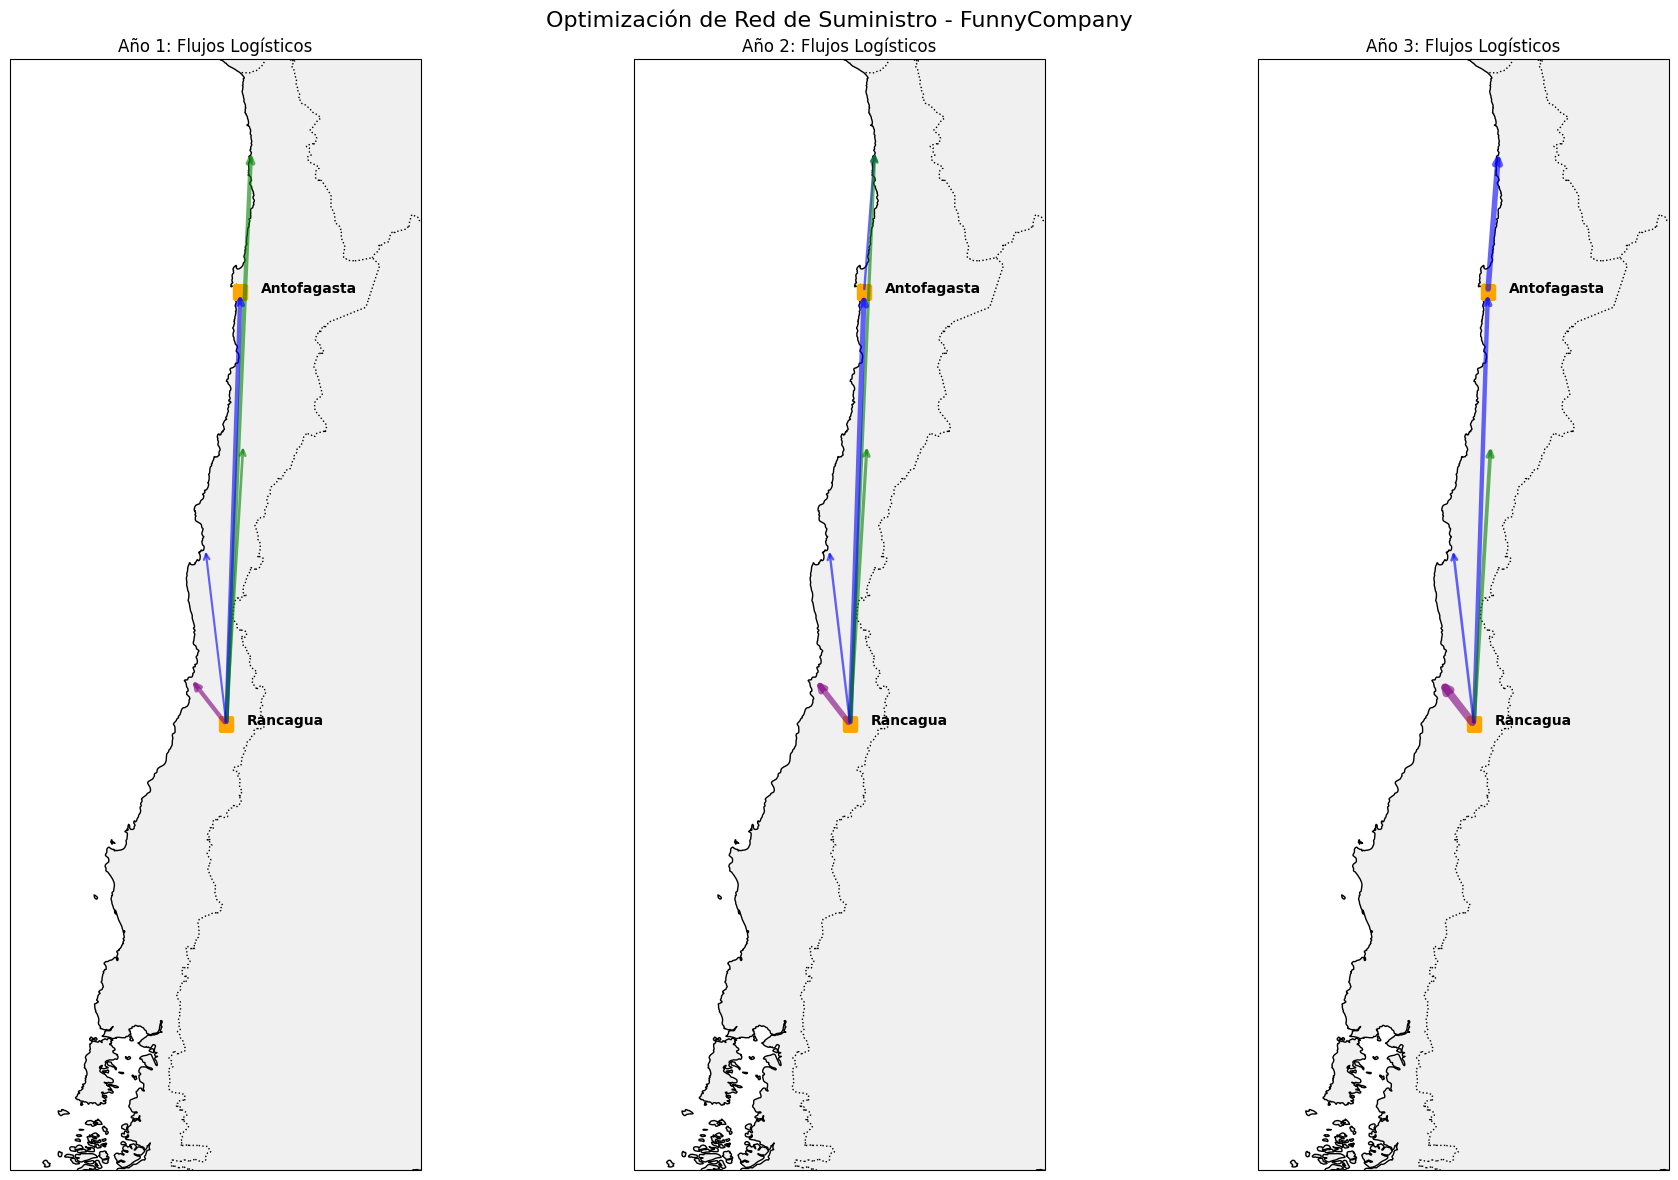

In [13]:
colores_transporte = {"AT1": "blue", "AT2": "green", "AT3": "purple"}

def visualizar_resultados(modelo, x, y, años, ciudades, regiones, transportes):
    if modelo.status != GRB.OPTIMAL:
        print("El modelo no es óptimo, no se puede visualizar.")
        return

    fig, axs = plt.subplots(1, len(años), figsize=(20, 12),
                            subplot_kw={'projection': ccrs.PlateCarree()})

    if len(años) == 1: axs = [axs]

    for idx, an in enumerate(años):
        ax = axs[idx]
        ax.set_extent([-76, -66, -45, -18], crs=ccrs.PlateCarree())

        ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')

        for c in ciudades:
            for p in tipos_planta:
                if y[c, p].X > 0.5:
                    lat, lon = coords[c]
                    color = 'red' if p == "Grande" else 'orange'
                    ax.plot(lon, lat, marker='s', color=color, markersize=10,
                            label=f'Planta {p}' if idx == 0 else "")
                    ax.text(lon + 0.5, lat, c, fontweight='bold')

        max_flow = max([x[c, r, t, a].X for c in ciudades for r in regiones for t in transportes for a in años] + [1])

        for c in ciudades:
            for r in regiones:
                for t in transportes:
                    valor_flujo = x[c, r, t, an].X
                    if valor_flujo > 0.1:
                        start_lat, start_lon = coords[c]
                        end_lat, end_lon = coords[r]

                        lw = (valor_flujo / max_flow) * 5 + 0.5

                        ax.annotate('', xy=(end_lon, end_lat), xytext=(start_lon, start_lat),
                                    arrowprops=dict(arrowstyle='->',
                                                   color=colores_transporte[t],
                                                   lw=lw, alpha=0.6))

        ax.set_title(f"Año {an}: Flujos Logísticos")

    plt.suptitle("Optimización de Red de Suministro - FunnyCompany", fontsize=16)
    plt.tight_layout()
    plt.savefig("mapa_logistica_funnycompany.png", dpi=300, bbox_inches='tight')
    plt.show()

visualizar_resultados(m, x, y, años, ciudades, regiones, transportes)